In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\server_3_working_hours_predictions.csv"
)

print(df.shape)
df.head()

(1944, 6)


,host_id,hostName,Timestamp,Actual_CPU_Usage,Predicted_CPU_Usage,Forecast_Type
0,3,10.10.10.2,2026-05-25 09:00:00+00:00,28.0,28.701757,Test
1,3,10.10.10.2,2026-05-25 09:05:00+00:00,28.0,27.575222,Test
2,3,10.10.10.2,2026-05-25 09:10:00+00:00,28.0,28.566841,Test
3,3,10.10.10.2,2026-05-25 09:15:00+00:00,29.0,27.985332,Test
4,3,10.10.10.2,2026-05-25 09:20:00+00:00,29.0,27.977209,Test


In [3]:
# timestamp processing
df['Timestamp'] = pd.to_datetime(
    df['Timestamp'],
    format='mixed',
    utc=True
)

df = df.sort_values(
    'Timestamp'
).reset_index(drop=True)

print(df['host_id'].unique())
print(df['hostName'].unique())

SERVER_NAME = df['hostName'].iloc[0]

print(SERVER_NAME)

[3]
['10.10.10.2']
10.10.10.2


In [4]:
# X_future = df[
#     [
#         'Predicted_1hr'
#     ]
# ]
X_future = df[
    [
        'Predicted_CPU_Usage'
    ]
]

In [5]:
iso_future = IsolationForest(
    contamination=0.005,
    n_estimators=300,
    random_state=42
)

iso_future.fit(
    X_future
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.005
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [6]:
# predict future anomalies
df['future_score'] = (
    iso_future.decision_function(
        X_future
    )
)
df['future_pred'] = (
    iso_future.predict(
        X_future
    )
)

In [7]:
df['future_anomaly'] = (
    df['future_pred'] == -1
)
print(
    df['future_anomaly']
    .value_counts()
)

future_anomaly
False    1934
True       10
Name: count, dtype: int64


In [8]:
# Future anomalies table
future_anomalies = df[
    df['future_anomaly']
].copy()
future_anomalies = future_anomalies[
    [
        'host_id',
        'hostName',
        'Timestamp',
        # 'Predicted_1hr',
        'Predicted_CPU_Usage',
        'future_score'
    ]
]
future_anomalies

,host_id,hostName,Timestamp,Predicted_CPU_Usage,future_score
1300,3,10.10.10.2,2026-06-06 09:20:00+00:00,30.904057,-0.002521
1301,3,10.10.10.2,2026-06-06 09:25:00+00:00,31.008980,-0.025324
1333,3,10.10.10.2,2026-06-06 12:05:00+00:00,30.931522,-0.007411
1338,3,10.10.10.2,2026-06-06 12:30:00+00:00,31.026495,-0.029330
1347,3,10.10.10.2,2026-06-06 13:15:00+00:00,30.916420,-0.004136
1370,3,10.10.10.2,2026-06-06 15:10:00+00:00,31.067371,-0.031510
1441,3,10.10.10.2,2026-06-07 12:05:00+00:00,31.022545,-0.029163
1865,3,10.10.10.2,2026-06-11 11:25:00+00:00,27.141966,-0.001769
1895,3,10.10.10.2,2026-06-11 13:55:00+00:00,27.102913,-0.005486
1920,3,10.10.10.2,2026-06-11 16:00:00+00:00,27.132261,-0.002737


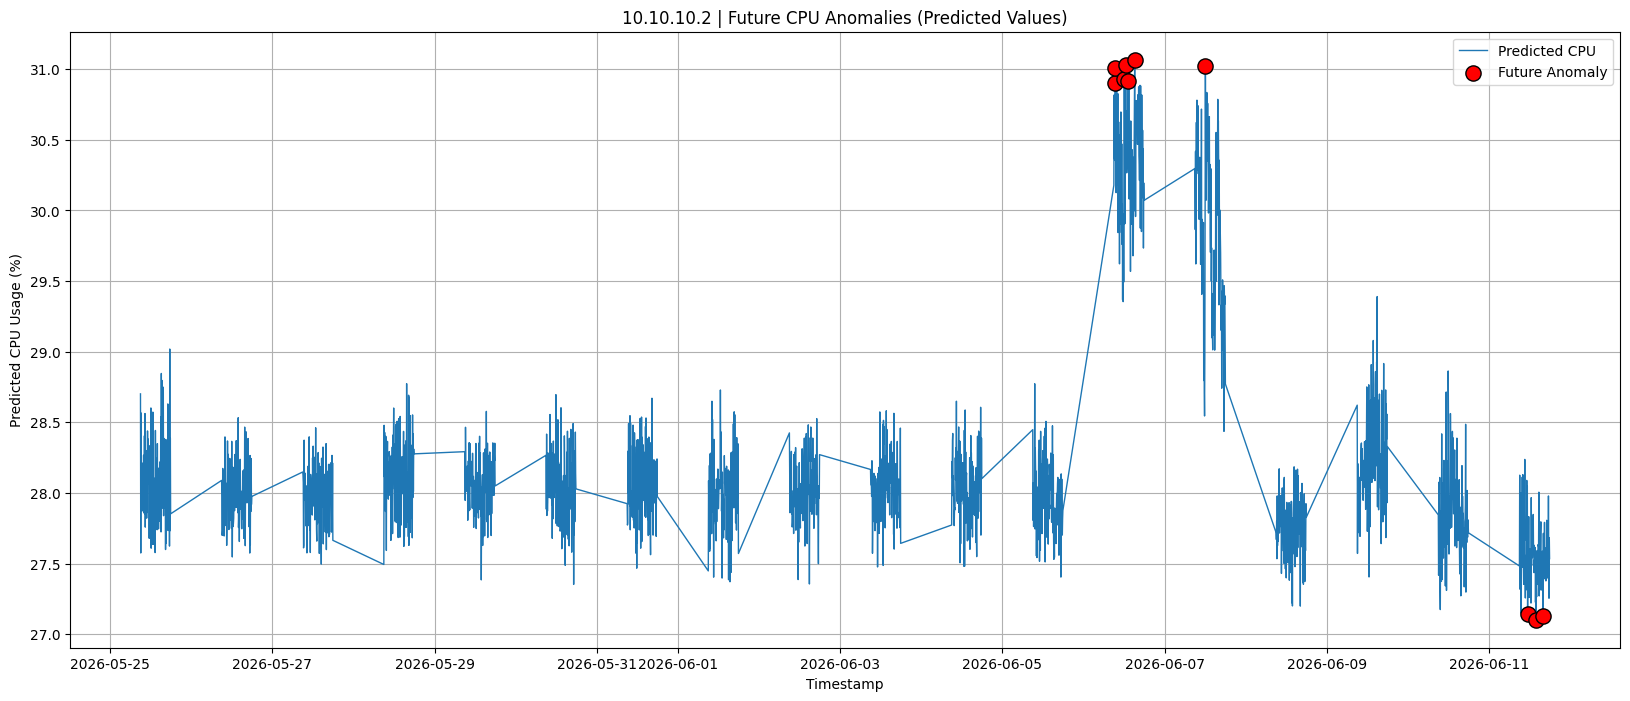

In [9]:
plt.figure(
    figsize=(20,8)
)
plt.plot(
    df['Timestamp'],
    # df['Predicted_1hr'],
    df['Predicted_CPU_Usage'],
    linewidth=1,
    label='Predicted CPU'
)
plt.scatter(
    df.loc[
        df['future_anomaly'],
        'Timestamp'
    ],
    df.loc[
        df['future_anomaly'],
        'Predicted_CPU_Usage'
    ],
    color='red',
    s=120,
    edgecolors='black',
    zorder=20,
    label='Future Anomaly'
)
plt.title(
    f'{SERVER_NAME} | Future CPU Anomalies (Predicted Values)'
)
plt.xlabel(
    'Timestamp'
)
plt.ylabel(
    'Predicted CPU Usage (%)'
)
plt.legend()
plt.grid(True)
plt.show()

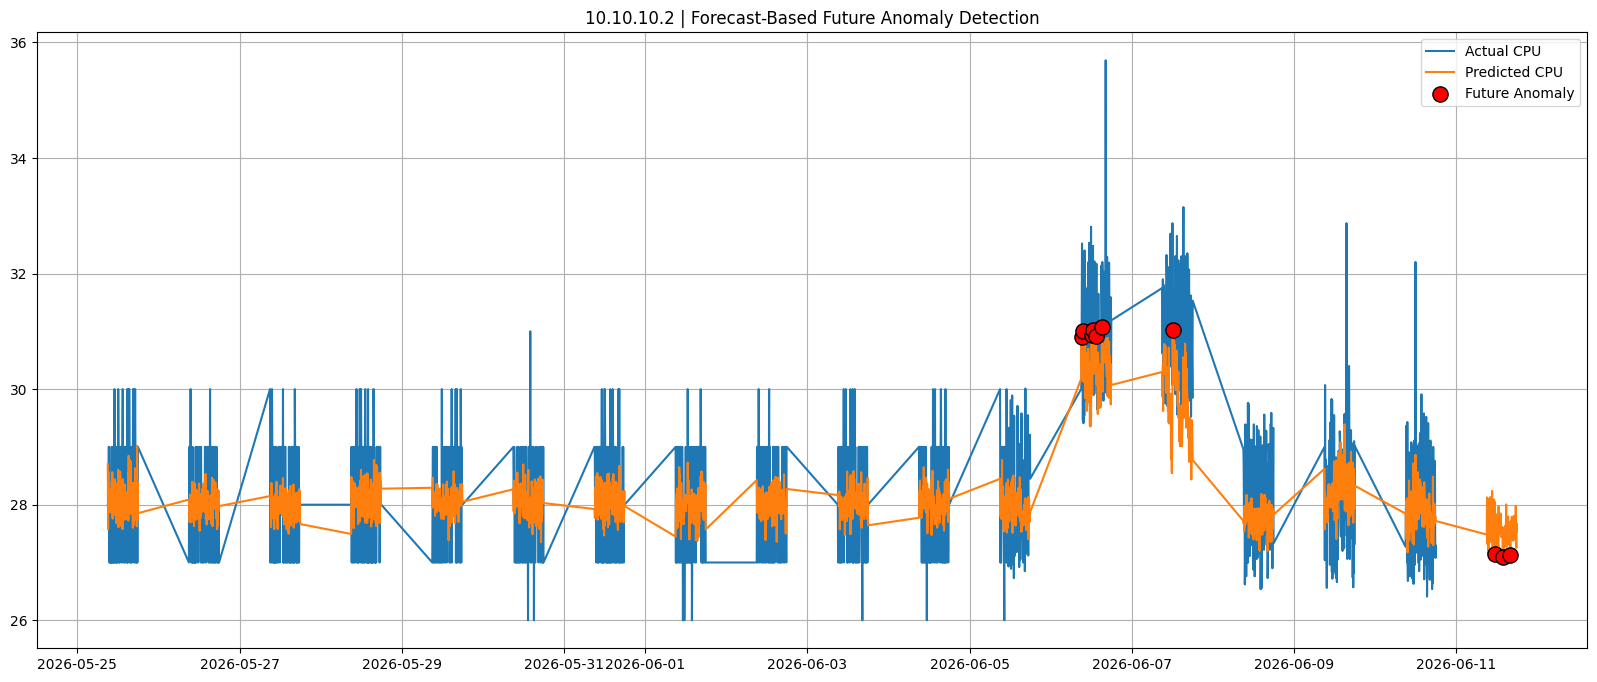

In [10]:
plt.figure(
    figsize=(20,8)
)
plt.plot(
    df['Timestamp'],
    # df['Actual_1hr'],
    df['Actual_CPU_Usage'],
    label='Actual CPU'
)
plt.plot(
    df['Timestamp'],
    # df['Predicted_1hr'],
    df['Predicted_CPU_Usage'],
    label='Predicted CPU'
)
plt.scatter(
    df.loc[
        df['future_anomaly'],
        'Timestamp'
    ],
    df.loc[
        df['future_anomaly'],
        'Predicted_CPU_Usage'
    ],
    color='red',
    s=120,
    edgecolors='black',
    zorder=20,
    label='Future Anomaly'
)
plt.title(
    f'{SERVER_NAME} | Forecast-Based Future Anomaly Detection'
)
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# =====================================
# INTERACTIVE FUTURE ANOMALY PLOT
# =====================================

import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"
fig = go.Figure()
# Predicted CPU Line
fig.add_trace(
    go.Scatter(
        x=df['Timestamp'],
        # y=df['Predicted_1hr'],
        y=df['Predicted_CPU_Usage'],
        mode='lines',
        name='Predicted CPU',
        line=dict(width=1)
    )
)
# Future Anomaly Markers
fig.add_trace(
    go.Scatter(
        x=future_anomalies['Timestamp'],
        y=future_anomalies['Predicted_CPU_Usage'],
        mode='markers+text',
        name='Future Anomaly',
        marker=dict(
            color='red',
            size=12,
            line=dict(
                color='black',
                width=1
            )
        ),
        text=[
            ts.strftime("%d-%m-%Y %H:%M")
            for ts in future_anomalies['Timestamp']
        ],
        textposition="top center",
        hovertemplate=
        "<b>Timestamp:</b> %{text}<br>" +
        "<b>Predicted CPU:</b> %{y:.2f}%<br>" +
        "<extra></extra>"
    )
)
fig.update_layout(
    title=
    f"{SERVER_NAME} | Future CPU Anomalies (Predicted Values)",
    xaxis_title="Timestamp",
    yaxis_title="Predicted CPU Usage (%)",
    hovermode='closest',
    height=800
)
fig.show()

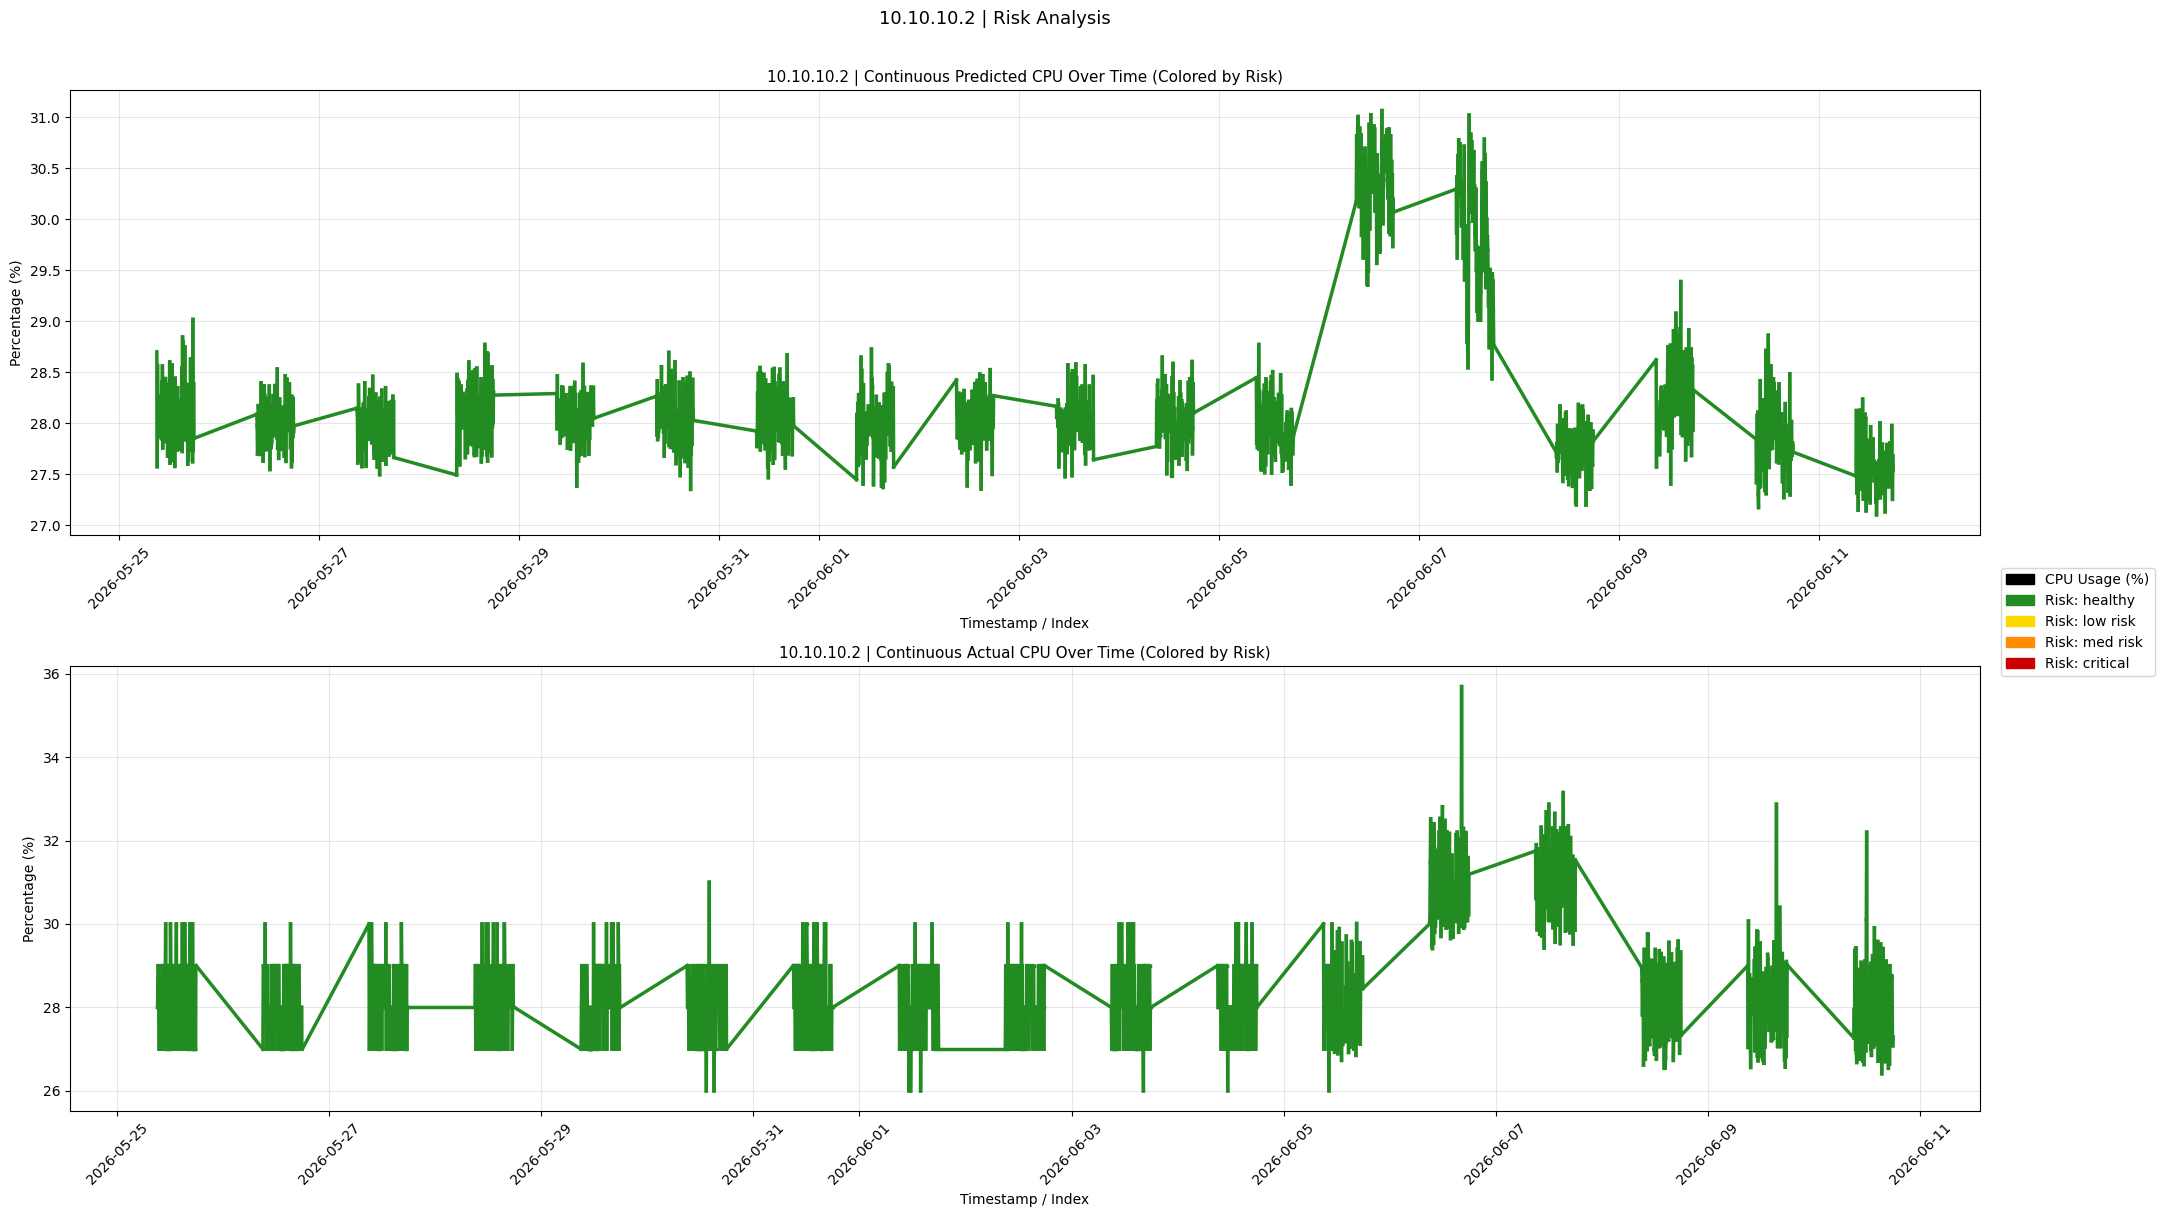

In [12]:
# =====================================
# RISK ANALYSIS — Continuous Line Colored by Risk
# (Predicted_1hr and Actual_1hr, colored by risk tier)
# =====================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# --- Define risk tiers for CPU usage ---
def get_cpu_risk(cpu_val):
    if cpu_val >= 90:
        return 'critical'
    elif cpu_val >= 75:
        return 'med risk'
    elif cpu_val >= 60:
        return 'low risk'
    else:
        return 'healthy'
RISK_COLORS = {
    'healthy':  '#228B22',
    'low risk': '#FFD700',
    'med risk': '#FF8C00',
    'critical': '#CC0000',
}
def plot_risk_line(ax, plot_df, value_col, title):
    """Draw a continuous line colored by risk tier."""
    plot_df = plot_df[['Timestamp', value_col]].dropna().copy()
    plot_df = plot_df.sort_values('Timestamp').reset_index(drop=True)
    plot_df['risk'] = plot_df[value_col].apply(get_cpu_risk)

    # Black backbone
    ax.plot(plot_df['Timestamp'], plot_df[value_col],
            color='black', linewidth=1.2, zorder=1, label=value_col)

    # Colored segments
    for i in range(len(plot_df) - 1):
        risk = plot_df['risk'].iloc[i]
        ax.plot(
            plot_df['Timestamp'].iloc[i:i+2],
            plot_df[value_col].iloc[i:i+2],
            color=RISK_COLORS[risk],
            linewidth=2.5,
            zorder=2
        )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Timestamp / Index')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# --- Legend patches ---
patches = [mpatches.Patch(color='black', label='CPU Usage (%)')]
for label, color in RISK_COLORS.items():
    patches.append(mpatches.Patch(color=color, label=f'Risk: {label}'))

# --- Two-panel figure ---
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=False)

plot_risk_line(
    axes[0], df, 'Predicted_CPU_Usage',
    f'{SERVER_NAME} | Continuous Predicted CPU Over Time (Colored by Risk)'
)

plot_risk_line(
    axes[1], df, 'Actual_CPU_Usage',
    f'{SERVER_NAME} | Continuous Actual CPU Over Time (Colored by Risk)'
)

# Add shared legend to the right of the figure
fig.legend(
    handles=patches,
    loc='center right',
    bbox_to_anchor=(1.08, 0.5),
    borderaxespad=0
)

plt.suptitle(f'{SERVER_NAME} | Risk Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# =====================================
# RISK ANALYSIS — Clean Single Line, Training Set (cpu_baseline.csv)
# =====================================

# train_df = pd.read_csv(
#     r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv"
# )
# train_df['ts'] = pd.to_datetime(train_df['ts'], format='mixed', utc=True)

# # If this file has multiple servers, filter to the one in df
# server_id = df['host_id'].iloc[0]
# train_df = train_df[train_df['host_id'] == server_id].sort_values('ts')

# train_plot = (
#     train_df.set_index('ts')['cpu_usage_pct']
#     .resample('1h').mean()
#     .dropna()
#     .reset_index()
# )
# train_plot.columns = ['ts', 'cpu_usage_pct']
# train_plot['risk'] = train_plot['cpu_usage_pct'].apply(get_cpu_risk)

# fig, ax = plt.subplots(figsize=(20, 5))

# ax.plot(train_plot['ts'], train_plot['cpu_usage_pct'],
#         color='black', linewidth=1.2, zorder=1)

# for i in range(len(train_plot) - 1):
#     risk = train_plot['risk'].iloc[i]
#     ax.plot(
#         train_plot['ts'].iloc[i:i+2],
#         train_plot['cpu_usage_pct'].iloc[i:i+2],
#         color=RISK_COLORS[risk], linewidth=2.5, zorder=2
#     )

# patches = [mpatches.Patch(color='black', label='CPU Usage (%)')]
# for label, color in RISK_COLORS.items():
#     patches.append(mpatches.Patch(color=color, label=f'Risk: {label}'))

# ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
# ax.set_title(f'{SERVER_NAME} | Continuous CPU Usage — Training Set (Colored by Risk)', fontsize=13)
# ax.set_xlabel('Timestamp')
# ax.set_ylabel('CPU Usage (%)')
# ax.tick_params(axis='x', rotation=45)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()